# California Housing Price Analysis and Linear Model

This code loads the California housing dataset and performs three key analyses:
1. Visualizes the relationship between median income and house values
2. Fits a linear model using SVD (Singular Value Decomposition) to predict house values
3. Shows the influence of each feature on house prices through a bar chart visualization

The dataset contains 20,640 observations with 8 features describing California
housing districts including median income, housing age, average rooms, etc.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the California housing dataset
housing_data, housing_value = fetch_california_housing(return_X_y=True)
labels = fetch_california_housing().feature_names
print("Feature names:", labels)
print("Shape of housing data:", housing_data.shape)
print("Shape of housing values:", housing_value.shape)


Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape of housing data: (20640, 8)
Shape of housing values: (20640,)


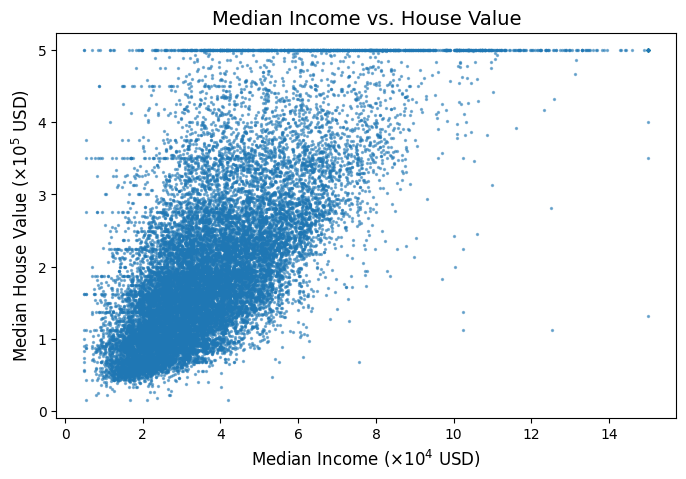

In [3]:
# Plot relationship between median income and house values
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(housing_data[:, 0], housing_value, s=2, alpha=0.5)
ax.set_xlabel('Median Income ($\\times 10^4$ USD)', fontsize=12)
ax.set_ylabel('Median House Value ($\\times 10^5$ USD)', fontsize=12)
ax.set_title('Median Income vs. House Value', fontsize=14)
plt.show()


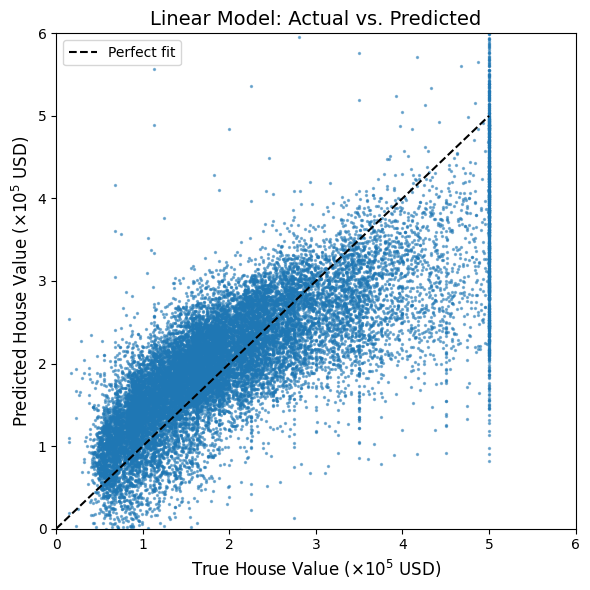

In [4]:
# Normalize the data
housing_data = (housing_data - np.mean(housing_data, axis=0)) / np.std(housing_data, axis=0)

# Prepare data for SVD by adding intercept term
housing_data = np.pad(housing_data, ((0, 0), (0, 1)), mode='constant', constant_values=1)

# Perform SVD and fit linear model
U, S, Vt = np.linalg.svd(housing_data, full_matrices=False)
x = Vt.T @ np.linalg.inv(np.diag(S)) @ U.T @ housing_value  # Calculate feature coefficients

# Predict data
predicted = housing_data @ x

# Plot actual vs predicted house values
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(housing_value, predicted, s=2, alpha=0.5)
ax.plot([0, 5], [0, 5], 'k--', linewidth=1.5, label='Perfect fit')
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel('True House Value ($\\times 10^5$ USD)', fontsize=12)
ax.set_ylabel('Predicted House Value ($\\times 10^5$ USD)', fontsize=12)
ax.set_title('Linear Model: Actual vs. Predicted', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


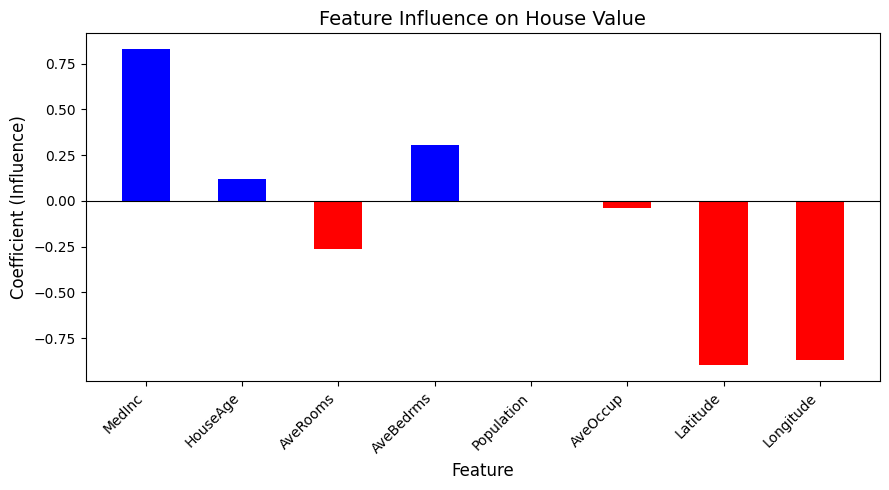

In [ ]:
# Visualize feature importance
x_tick = range(1, len(x))
colors = ['blue' if v > 0 else 'red' for v in x]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_tick, x[:-1], width=0.5, color=colors) # Exclude the last term (intercept)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Coefficient (Influence)', fontsize=12)
ax.set_title('Feature Influence on House Value', fontsize=14)
ax.set_xticks(x_tick)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()
